# FLEXIMOD market result quick analysis

Small notebook for checking market electricity procurement and market cost/revenue components.

Expected result files in `RESULTS_DIR`:

- `market_ledger.csv` preferred for market positions and settlement values
- `dispatch_results.csv` used as fallback
- `summary_indicators.csv` optional


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Change this to the output folder of the case you want to analyse.
RESULTS_DIR = Path("../data/output/steel_plant_DE_steel_cost_minimization")

RESULTS_DIR.resolve()

WindowsPath('C:/Users/khm/Models/FLEXIMOD/data/output/steel_plant_DE_steel_cost_minimization')

In [7]:
def read_optional_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Missing: {path.name}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    print(f"Loaded {path.name}: {len(df):,} rows, {len(df.columns):,} columns")
    return df


market = read_optional_csv(RESULTS_DIR / "market_ledger.csv")
dispatch = read_optional_csv(RESULTS_DIR / "dispatch_results.csv")
summary = read_optional_csv(RESULTS_DIR / "summary_indicators.csv")

market.head() if not market.empty else dispatch.head()

Missing: market_ledger.csv
Loaded dispatch_results.csv: 34,848 rows, 46 columns
Loaded summary_indicators.csv: 1 rows, 28 columns


,datetime,plant_name,plant_type,steel_route,steel_demand_mode,steel_demand_total_t,total_electricity_consumption_MWh,variable_cost_EUR,coal_consumption_MWh,co2_emissions_t,...,bf_bof_lime_consumption_t,bf_bof_co2_emissions_t,bf_bof_operational_status,solver,rolling_window,steel_horizon_target_t,steel_committed_output_t,cumulative_steel_output_t,remaining_steel_demand_t,steel_demand_balance_t
0,2030-01-02 00:00:00,P100000120423_dri_eaf_coal_external,steel_plant,dri_eaf,forecast_profile,1.291772e+06,20.178341,24825.577426,199.49907,0.190362,...,0.0,0.0,0,highs,1,7137.683649,3654.9448,38.072342,1.291734e+06,-1.408563
1,2030-01-02 00:15:00,P100000120423_dri_eaf_coal_external,steel_plant,dri_eaf,forecast_profile,1.291772e+06,20.178341,24825.577426,199.49907,0.190362,...,0.0,0.0,0,highs,1,7137.683649,3654.9448,76.144683,1.291696e+06,-2.817126
2,2030-01-02 00:30:00,P100000120423_dri_eaf_coal_external,steel_plant,dri_eaf,forecast_profile,1.291772e+06,20.178341,24825.577426,199.49907,0.190362,...,0.0,0.0,0,highs,1,7137.683649,3654.9448,114.217025,1.291658e+06,-4.225689
3,2030-01-02 00:45:00,P100000120423_dri_eaf_coal_external,steel_plant,dri_eaf,forecast_profile,1.291772e+06,20.178341,24825.577426,199.49907,0.190362,...,0.0,0.0,0,highs,1,7137.683649,3654.9448,152.289367,1.291620e+06,-5.634252
4,2030-01-02 01:00:00,P100000120423_dri_eaf_coal_external,steel_plant,dri_eaf,forecast_profile,1.291772e+06,20.178341,24825.577426,199.49907,0.190362,...,0.0,0.0,0,highs,1,7137.683649,3654.9448,190.361708,1.291582e+06,-7.042815


In [8]:
def numeric_series(df: pd.DataFrame, column: str, default: float = 0.0) -> pd.Series:
    if df.empty or column not in df.columns:
        return pd.Series([default], dtype=float)
    return pd.to_numeric(df[column], errors="coerce").fillna(default)


def column_sum(df: pd.DataFrame, column: str) -> float:
    return float(numeric_series(df, column).sum())


def first_existing(df: pd.DataFrame, columns: list[str]) -> str | None:
    for column in columns:
        if not df.empty and column in df.columns:
            return column
    return None


def weighted_value(df: pd.DataFrame, quantity_col: str, price_col: str) -> float:
    if df.empty or quantity_col not in df.columns or price_col not in df.columns:
        return 0.0
    quantity = pd.to_numeric(df[quantity_col], errors="coerce").fillna(0.0)
    price = pd.to_numeric(df[price_col], errors="coerce").fillna(0.0)
    return float((quantity * price).sum())

## Electricity procurement by market

This plot answers: how much electricity came from day-ahead, intraday buy/sell, and activated aFRR down energy?

,market,electricity_MWh


ValueError: Invalid color argument: []

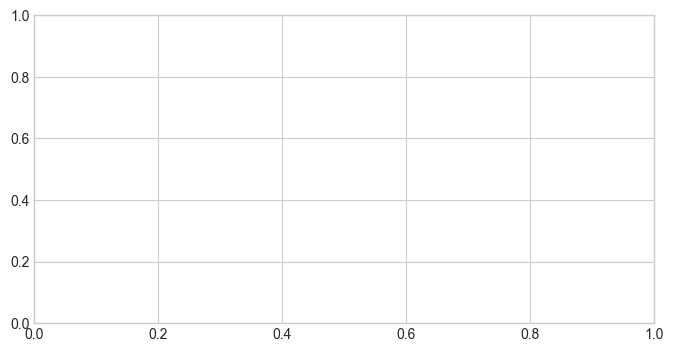

In [9]:
source = market if not market.empty else dispatch

procurement = {
    "Day-ahead procurement": column_sum(
        source,
        first_existing(source, ["day_ahead_position_MWh_el", "DA_position_MWh"]) or "",
    ),
    "Intraday buy": column_sum(
        source,
        first_existing(source, ["intraday_buy_MWh_el", "IDC_buy_MWh"]) or "",
    ),
    "Intraday sell": -column_sum(
        source,
        first_existing(source, ["intraday_sell_MWh_el", "IDC_sell_MWh"]) or "",
    ),
    "aFRR activated energy": column_sum(
        source,
        first_existing(source, ["afrr_energy_activated_MWh_el", "afrr_energy_activated_MWh"]) or "",
    ),
}

procurement_df = pd.DataFrame(
    {"market": procurement.keys(), "electricity_MWh": procurement.values()}
).query("electricity_MWh != 0")

display(procurement_df)

ax = procurement_df.plot.bar(
    x="market",
    y="electricity_MWh",
    legend=False,
    color=["#4C78A8", "#72B7B2", "#F58518", "#B279A2"][: len(procurement_df)],
    figsize=(8, 4),
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Electricity [MWh_el]")
ax.set_xlabel("")
ax.set_title("Electricity procurement by market")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Market cost / revenue waterfall

Positive bars increase cost. Negative bars are revenues or sales that reduce net market cost.

The waterfall focuses on market-facing electricity settlement, not material input costs such as iron ore or lime.

,component,value_EUR
0,Net market cost,0.0


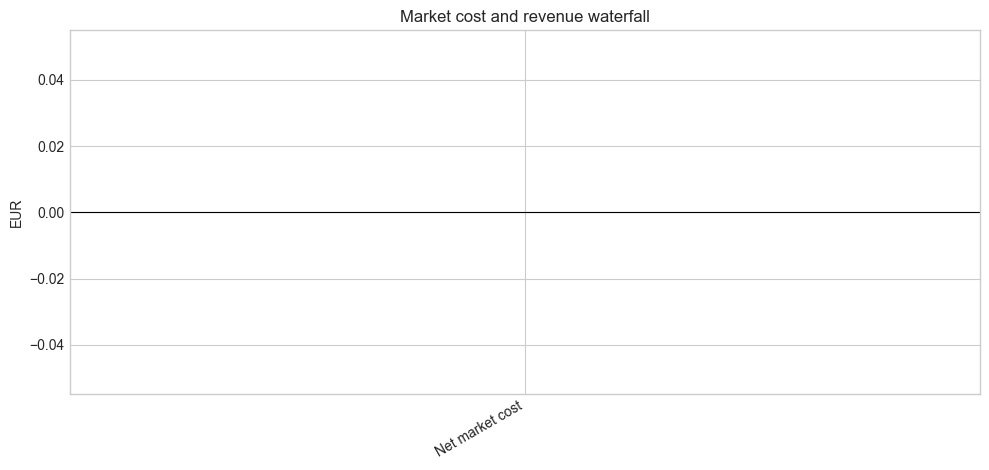

In [10]:
if not market.empty:
    components = {
        "Day-ahead electricity": weighted_value(
            market,
            "day_ahead_position_MWh_el",
            "day_ahead_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday buy": weighted_value(
            market,
            "intraday_buy_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "Intraday sell": -weighted_value(
            market,
            "intraday_sell_MWh_el",
            "intraday_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR energy settlement": weighted_value(
            market,
            "afrr_energy_activated_MWh_el",
            "afrr_energy_delivered_price_EUR_per_MWh_el",
        ),
        "aFRR capacity revenue": -column_sum(market, "afrr_capacity_revenue_EUR"),
    }
else:
    components = {
        "Electricity market cost": column_sum(dispatch, "electricity_market_cost_EUR"),
        "Additional electricity charges": column_sum(
            dispatch, "additional_electricity_charges_cost_EUR"
        ),
        "aFRR capacity revenue": -column_sum(dispatch, "afrr_capacity_revenue_EUR"),
    }

waterfall_df = pd.DataFrame(
    {"component": components.keys(), "value_EUR": components.values()}
).query("value_EUR != 0")
waterfall_df.loc[len(waterfall_df)] = ["Net market cost", waterfall_df["value_EUR"].sum()]

display(waterfall_df)

running = waterfall_df["value_EUR"].iloc[:-1].cumsum().shift(fill_value=0.0)
values = waterfall_df["value_EUR"].iloc[:-1]
labels = waterfall_df["component"].iloc[:-1].tolist()
net = waterfall_df["value_EUR"].iloc[-1]

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ["#D95F02" if value >= 0 else "#1B9E77" for value in values]
ax.bar(labels, values, bottom=running, color=colors)
ax.bar(["Net market cost"], [net], color="#4C78A8")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("EUR")
ax.set_title("Market cost and revenue waterfall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Optional: per-plant market procurement

Useful when the output contains several plants/routes.

In [11]:
if not market.empty and "plant_name" in market.columns:
    per_plant = market.groupby("plant_name", dropna=False).agg(
        day_ahead_MWh=("day_ahead_position_MWh_el", "sum"),
        afrr_activated_MWh=("afrr_energy_activated_MWh_el", "sum"),
        capacity_revenue_EUR=("afrr_capacity_revenue_EUR", "sum"),
    )
    display(per_plant)
    per_plant[["day_ahead_MWh", "afrr_activated_MWh"]].plot.bar(
        stacked=True,
        figsize=(10, 4),
        color=["#4C78A8", "#B279A2"],
    )
    plt.ylabel("Electricity [MWh_el]")
    plt.title("Electricity procurement by plant")
    plt.tight_layout()
else:
    print("No market_ledger.csv with plant_name column available.")

No market_ledger.csv with plant_name column available.
